# Final Report - Data Science
## Bachelor's Degree in Computer Science / PUCPR (2026-1)

**Prof. Rayson Laroca**

`Alander Menezes Arantes de Ávila` - `menezes.alander@pucpr.edu.br`

`Pedro Lucas Ghezzi Bittencourt` - `pedro.bittencourt@pucpr.edu.br`

`Paulo Henrique Perin` - `paulo.perin@pucpr.edu.br`

`Place your name here` - `and your email here`

`Place your name here` - `and your email here`

# Import the libs you need

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from google.colab import drive
from scipy.stats import skew as _skew, kurtosis as _kurt

# Add others as needed (seaborn, sklearn, etc.)

# Load your data

#### https://www.kaggle.com/datasets/sakhawat18/asteroid-dataset/data

Below, load the data using pandas and perform all necessary data cleaning to ensure that the data types are correct for further analysis.

In [2]:
df = pd.read_csv("asteroids.csv")

C:\Users\PEDRO GRU\AppData\Local\Temp\ipykernel_30952\665402308.py:1: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("asteroids.csv")


In [3]:
df.shape

(958524, 45)

### The complete dataset we selected contains 958,524 asteroid records and 45 columns. We do not use every parameter. We only want to investigate which orbital and physical features characterize potentially hazardous asteroids (pha = Y), compared to non-hazardous ones (pha = N).

In [4]:
df.columns

Index(['id', 'spkid', 'full_name', 'pdes', 'name', 'prefix', 'neo', 'pha', 'H',
       'diameter', 'albedo', 'diameter_sigma', 'orbit_id', 'epoch',
       'epoch_mjd', 'epoch_cal', 'equinox', 'e', 'a', 'q', 'i', 'om', 'w',
       'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld',
       'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w',
       'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'class',
       'rms'],
      dtype='object')

In [5]:
# clean and treat the data here

### We remove identifier columns (id, spkid, full_name, pdes, name, prefix, orbit_id): they identify catalog entries but do not describe physical or orbital properties for modelling. We also discard rows without a pha value (`pha = NaN`), since the label is required for supervised analysis.

In [6]:
# Rows with missing pha aren't relevant to us
df_clean = df.dropna(subset=['pha'])

# Columns with id parameters aren't needed
# we're not analysing individual cases
id_cols = ['id', 'spkid', 'full_name', 'pdes', 'name', 'prefix', 'orbit_id']
df_clean = df_clean.drop(columns=id_cols, errors='ignore')

In [7]:
df_clean.shape

(938603, 38)

In [8]:
df_clean.columns

Index(['neo', 'pha', 'H', 'diameter', 'albedo', 'diameter_sigma', 'epoch',
       'epoch_mjd', 'epoch_cal', 'equinox', 'e', 'a', 'q', 'i', 'om', 'w',
       'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld',
       'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w',
       'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'class',
       'rms'],
      dtype='object')

In [9]:
df_clean['pha'].value_counts()

pha
N    936537
Y      2066
Name: count, dtype: int64

In [10]:
df_clean["pha"].value_counts(normalize=True)

pha
N    0.997799
Y    0.002201
Name: proportion, dtype: float64

#### At this point we realize that there is a huge imbalance between the potentially hazardous object and the harmless ones. About 99.78% of the asteroids in the dataset don't represent any hazard to the Earth.

In [11]:
# use as many code and text cells as needed

# Statistical Description

In this section, you should report the key characteristics of the dataset, including but not limited to:
* Number of instances;
* Number of features;
* Number of classes;
* Class distribution.

#### Key characteristics of the dataset after cleaning:
* 938,603 instances;
* 38 features;
* 2 classes (`pha`= Yes/No);
* 99.78% harmless (`pha`= No) and 0.22% hazardous (`pha` = Yes)

In [12]:
# use as many code and text cells as needed

# Univariate data analysis

In this section, you should perform univariate data analysis on at least **20 variables**.

In the end, you should describe the main variables that are of your interest, and these should be accounted for in the next sections of the report.
The definition of each variable chosen should be clarified, so arbitrary selections are **not** accepted at this point.

For each variable plotted, make sure you determine the following:
1. The distribution of the data (Gaussian, binomial, exponential, etc.);
2. Skewness;
3. Kurtosis;
4. Mean, standard deviation, and what they stand for in the context of the dataset.

Ensure that each variable is **plotted correctly** based on its type. For instance, make sure scatterplots are not used for categorical data and so forth.

In [13]:
# place as many cells to plot the visualizations,
# as well as to describe the main findings

In [14]:
# if you realize you need to further clean your data here, there is no problem,
# yet, make sure you are describing the entire process and the rationale
# behind your choices

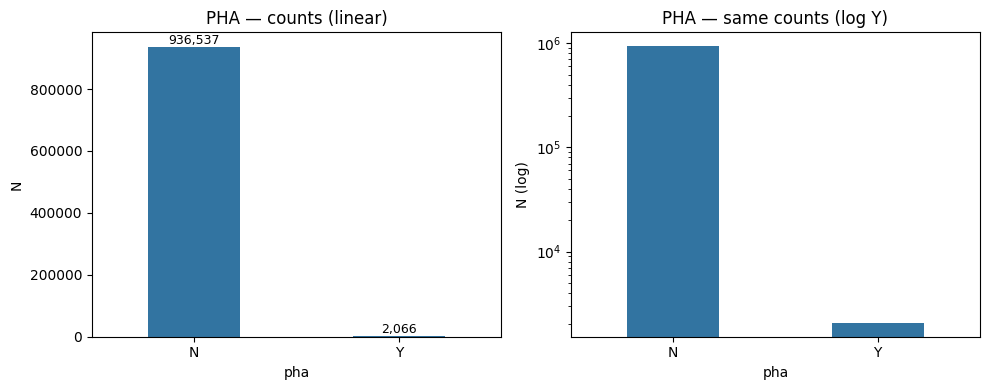

In [15]:
# Univariate 1: Real proportions of PHA

vc = df_clean["pha"].value_counts().reindex(["N", "Y"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(x=vc.index, y=vc.values, ax=axes[0], width=0.45)
axes[0].set_title("PHA — counts (linear)")
axes[0].set_xlabel("pha")
axes[0].set_ylabel("N")
for i, v in enumerate(vc.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

sns.barplot(x=vc.index, y=vc.values, ax=axes[1], width=0.45)
axes[1].set_yscale("log")
axes[1].set_title("PHA — same counts (log Y)")
axes[1].set_xlabel("pha")
axes[1].set_ylabel("N (log)")

plt.tight_layout()
plt.show()

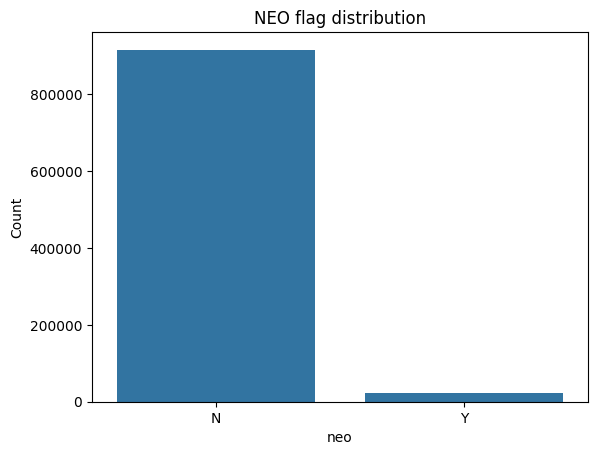

In [16]:
# Univariate 2: Real proportions of near-Earth flag

sns.countplot(data=df_clean, x="neo", order=df_clean["neo"].value_counts().index)
plt.title("NEO flag distribution")
plt.xlabel("neo")
plt.ylabel("Count")
plt.show()

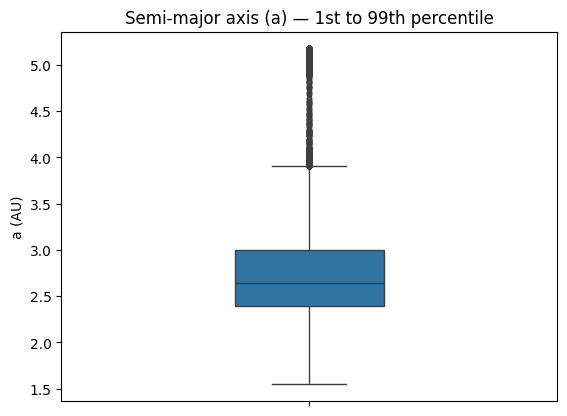

In [17]:
# Univariate 3: # average distance from the Sun in AU; defines the orbit's overall size

data = df_clean["a"].dropna()
p01, p99 = data.quantile(0.01), data.quantile(0.99)
sns.boxplot(data=data[(data >= p01) & (data <= p99)], width=0.3, fliersize=3)
plt.title("Semi-major axis (a) — 1st to 99th percentile")
plt.ylabel("a (AU)")
plt.show()

# Most objects orbit at ~2.6 AU (main belt); right-skewed with upper outliers from wider-orbit populations.

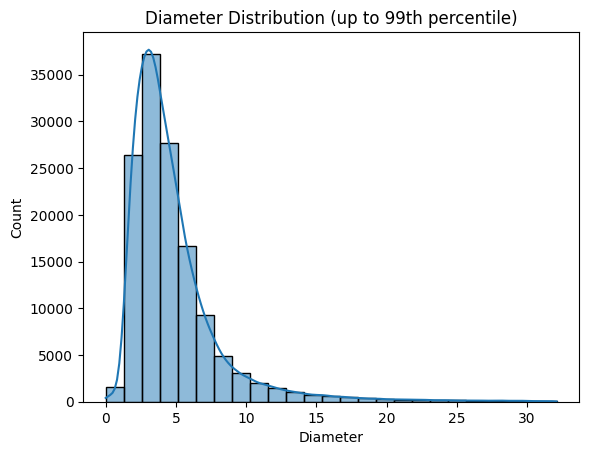

count    136209.000000
mean          5.506429
std           9.425164
min           0.002500
25%           2.780000
50%           3.972000
75%           5.765000
max         939.400000
Name: diameter, dtype: float64


In [18]:
# Univariate 5: physical size of the asteroid in km; only ~14% of rows have a measured diameter

data = df_clean.loc[df_clean['diameter'] > 0, 'diameter']

p99 = data.quantile(0.99)

sns.histplot(data[data <= p99], bins=25, kde=True)
plt.title('Diameter Distribution (up to 99th percentile)')
plt.xlabel('Diameter')
plt.ylabel('Count')
plt.show()

print(data.describe())

In [19]:
df_clean["diameter"].median()

np.float64(3.972)

*Most measured asteroids are small (under ~50 km), with a strong right skew — a few giants pull the tail. The median is much lower than the mean, confirming the skew. Note that diameter is only available for ~14% of the catalog, so this distribution reflects objects with size estimates (typically larger, brighter ones).*


In [20]:
# df_clean contém apenas pha em {'Y','N'}

# separar classes
df_y = df_clean[df_clean['pha'] == 'Y'].copy()
df_n = df_clean[df_clean['pha'] == 'N'].copy()

# amostra balanceada: mesma quantidade de N que de Y
n_bal = len(df_y)
df_n_bal = df_n.sample(n=n_bal, random_state=42)

# conjunto balanceado final
df_sample = pd.concat([df_y, df_n_bal], ignore_index=True)
df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)

# verificação
print("df_sample shape:", df_sample.shape)
print(df_sample['pha'].value_counts())
print(df_sample['pha'].value_counts(normalize=True))


df_sample shape: (4132, 38)
pha
Y    2066
N    2066
Name: count, dtype: int64
pha
Y    0.5
N    0.5
Name: proportion, dtype: float64


#### After a few univariate plots on the cleaned dataframe (df_clean), the strong class imbalance in pha is clear: there are many labeled instances overall, but only a small share are potentially hazardous (Y). That makes it hard to compare the two groups in the same figure when counts are plotted as-is. To explore which features differ between hazardous and non-hazardous objects, we therefore build a balanced sample (approximately equal numbers of Y and N) with a fixed random seed. Reported proportions and any claim about how rare Y is still come from df_clean; the balanced sample is used only to make exploratory plots easier to read and to compare distributions fairly between classes.



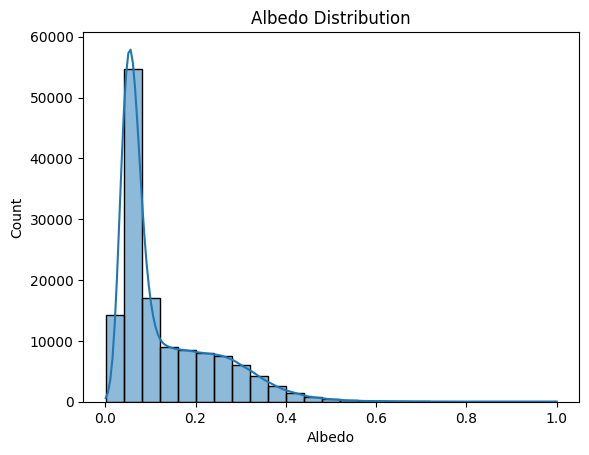

count    135103.000000
mean          0.130627
std           0.110323
min           0.001000
25%           0.053000
50%           0.079000
75%           0.190000
max           1.000000
Name: albedo, dtype: float64


In [21]:
data = df_clean.loc[df_clean['albedo'] > 0, 'albedo']

sns.histplot(data, bins=25, kde=True)
plt.title('Albedo Distribution')
plt.xlabel('Albedo')
plt.ylabel('Count')
plt.show()

print(data.describe())

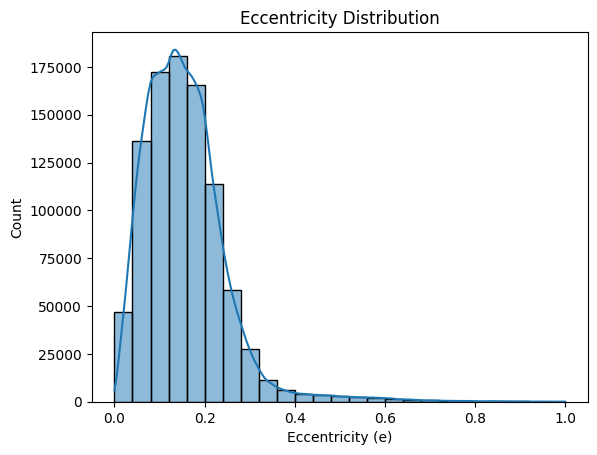

count    938599.000000
mean          0.156141
std           0.092975
min           0.000000
25%           0.092064
50%           0.144865
75%           0.200597
max           0.999851
Name: e, dtype: float64


In [22]:
data = df_clean.loc[(df_clean['e'] >= 0) & (df_clean['e'] < 1), 'e']

sns.histplot(data, bins=25, kde=True)
plt.title('Eccentricity Distribution')
plt.xlabel('Eccentricity (e)')
plt.ylabel('Count')
plt.show()

print(data.describe())

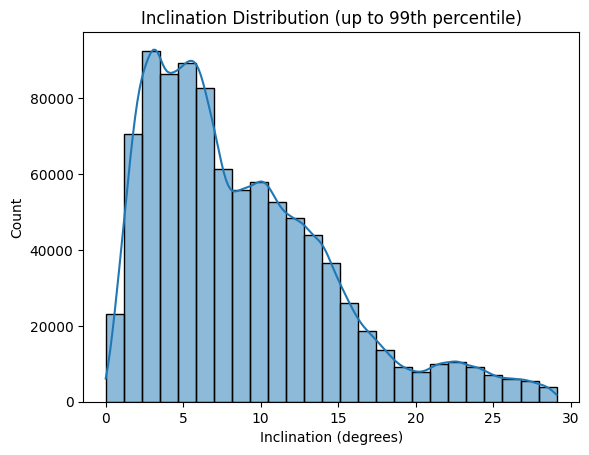

count    938603.000000
mean          9.048065
std           6.646721
min           0.007744
25%           4.154593
50%           7.404507
75%          12.398180
max         175.082901
Name: i, dtype: float64


In [23]:
data = df_clean.loc[df_clean['i'] >= 0, 'i']

p99 = data.quantile(0.99)

sns.histplot(data[data <= p99], bins=25, kde=True)
plt.title('Inclination Distribution (up to 99th percentile)')
plt.xlabel('Inclination (degrees)')
plt.ylabel('Count')
plt.show()

print(data.describe())

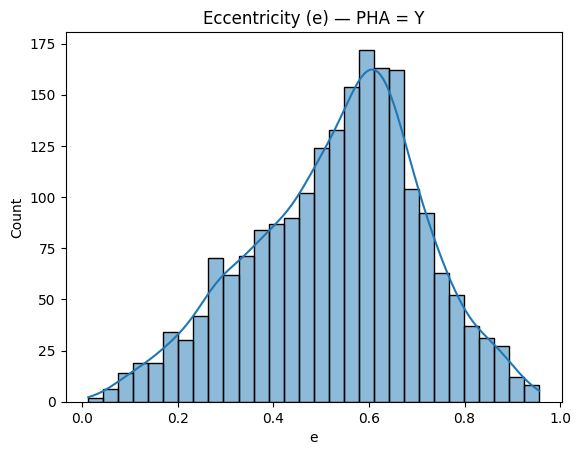

In [24]:
sns.histplot(df_sample[df_sample["pha"] == "Y"]["e"], bins=30, kde=True)
plt.title("Eccentricity (e) — PHA = Y")
plt.xlabel("e")
plt.ylabel("Count")
plt.show()

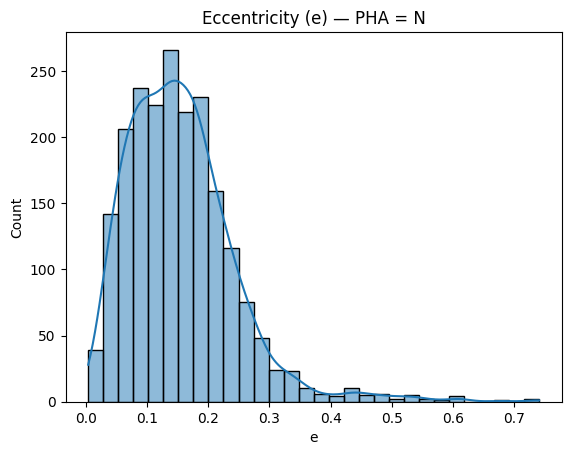

In [25]:
sns.histplot(df_sample[df_sample["pha"] == "N"]["e"], bins=30, kde=True)
plt.title("Eccentricity (e) — PHA = N")
plt.xlabel("e")
plt.ylabel("Count")
plt.show()

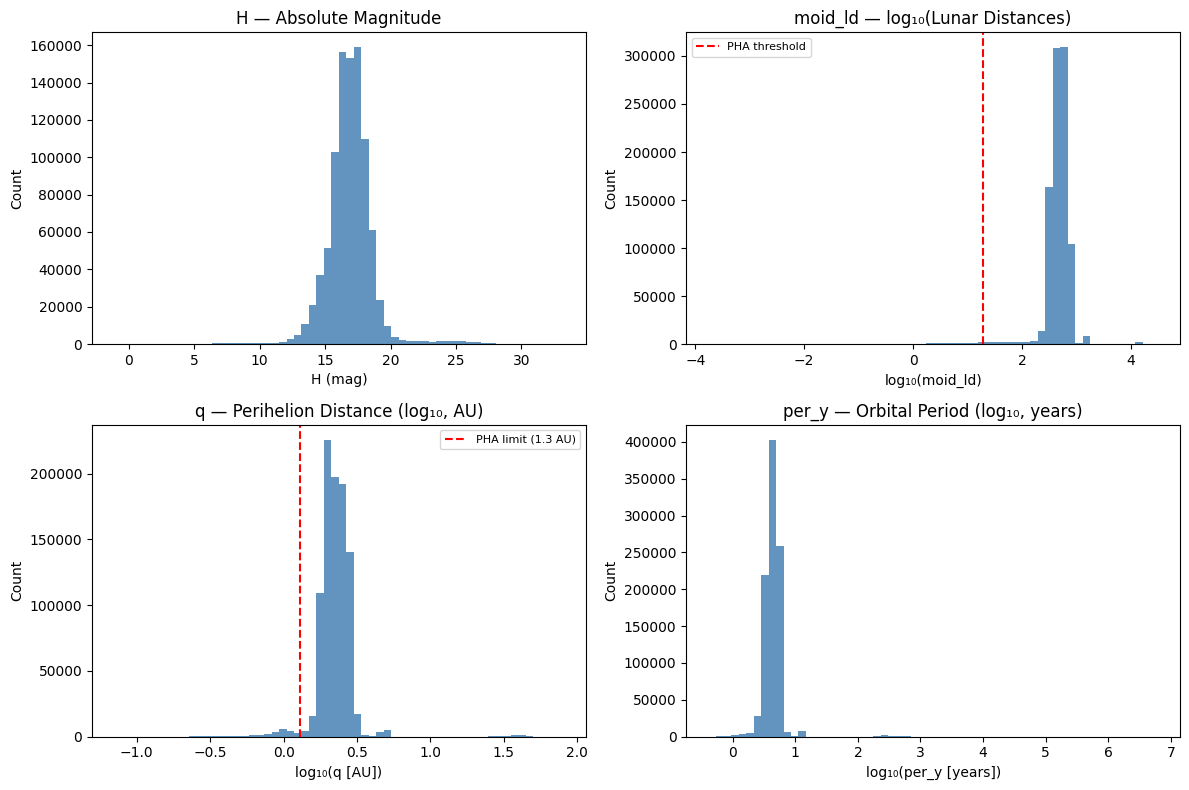

In [26]:
from scipy.stats import skew as _skew, kurtosis as _kurt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

# H
x_H = df_clean['H'].dropna()
axes[0].hist(x_H, bins=60, color='steelblue', alpha=0.85, edgecolor='none')
axes[0].set_title('H — Absolute Magnitude')
axes[0].set_xlabel('H (mag)')
axes[0].set_ylabel('Count')

# moid_ld (log10)
x_moid = df_clean['moid_ld'].dropna()
x_moid = x_moid[x_moid > 0]
axes[1].hist(np.log10(x_moid), bins=60, color='steelblue', alpha=0.85, edgecolor='none')
axes[1].set_title('moid_ld — log₁₀(Lunar Distances)')
axes[1].set_xlabel('log₁₀(moid_ld)')
axes[1].set_ylabel('Count')
axes[1].axvline(np.log10(19.5), color='red', linestyle='--', label='PHA threshold')
axes[1].legend(fontsize=8)

# q (log10)
x_q = df_clean['q'].dropna()
x_q = x_q[x_q > 0]
axes[2].hist(np.log10(x_q), bins=60, color='steelblue', alpha=0.85, edgecolor='none')
axes[2].set_title('q — Perihelion Distance (log₁₀, AU)')
axes[2].set_xlabel('log₁₀(q [AU])')
axes[2].set_ylabel('Count')
axes[2].axvline(np.log10(1.3), color='red', linestyle='--', label='PHA limit (1.3 AU)')
axes[2].legend(fontsize=8)

# per_y (log10)
x_per = df_clean['per_y'].dropna()
x_per = x_per[x_per > 0]
axes[3].hist(np.log10(x_per), bins=60, color='steelblue', alpha=0.85, edgecolor='none')
axes[3].set_title('per_y — Orbital Period (log₁₀, years)')
axes[3].set_xlabel('log₁₀(per_y [years])')
axes[3].set_ylabel('Count')

plt.tight_layout()
plt.show()


In [27]:
vars_info = [
    ('H',       df_clean['H'].dropna(),                                                   False),
    ('moid_ld', np.log10(df_clean['moid_ld'].dropna()[df_clean['moid_ld'].dropna() > 0]), True),
    ('q',       np.log10(df_clean['q'].dropna()[df_clean['q'].dropna() > 0]),             True),
    ('per_y',   np.log10(df_clean['per_y'].dropna()[df_clean['per_y'].dropna() > 0]),     True),
]

header = f"{'Variable':<16} {'Transform':<10} {'N':>9} {'Mean':>10} {'Std':>10} {'Skewness':>10} {'Kurtosis':>10}"
print(header)
print('-' * len(header))
for name, x, logged in vars_info:
    label = f'log10({name})' if logged else name
    tr = 'log10' if logged else 'none'
    print(f"{label:<16} {tr:<10} {len(x):>9,} {x.mean():>10.4f} {x.std():>10.4f} {_skew(x):>10.4f} {_kurt(x):>10.4f}")


Variable         Transform          N       Mean        Std   Skewness   Kurtosis
---------------------------------------------------------------------------------
H                none         932,341    16.8900     1.8014     0.6269     9.4996
log10(moid_ld)   log10        938,603     2.6569     0.3056    -4.6134    42.0378
log10(q)         log10        938,603     0.3499     0.1258     2.2818    35.5403
log10(per_y)     log10        938,599     0.6406     0.1615     6.2353    83.5835


#### Variable (Paulo) 1 — `H`: Absolute Magnitude

**Definition:** H is a logarithmic brightness measure at standard conditions (zero phase angle, 1 AU from Sun and observer). Lower H = brighter = typically larger object. The PHA size criterion is H ≤ 22 (diameter ≥ ~140 m).

**Distribution:** **Right-skewed unimodal**, peaking around H = 15–17. The catalog contains vastly more small/faint bodies than large/bright ones — a direct result of collisional fragmentation.

**Skewness:** Positive and high — long right tail toward very faint (small) objects.

**Kurtosis:** Leptokurtic (positive excess) — sharper peak and heavier tails than Gaussian.

**Mean and Std in context:** Mean H ≈ 16 corresponds to ~1–2 km diameter at typical albedo. Large std reflects the catalog range from dwarf planets (H ≈ 0–4) to sub-100 m rocks (H > 22). PHAs occupy the lower-H (larger/brighter) end.

#### Variable (Paulo) 2 — `moid_ld`: MOID in Lunar Distances

**Definition:** Minimum geometric distance between the asteroid's orbit and Earth's orbit, in lunar distances (1 AU ≈ 389.17 LD). PHA proximity criterion: **moid_ld ≤ 19.5 LD** (~0.05 AU). Log₁₀ transform applied due to the wide value range.

**Distribution:** **Strongly bimodal** in raw form. After log₁₀ transform: a left cluster of NEOs/PHAs (small MOID) and a large right mass of main-belt asteroids (MOID >> 19.5 LD). Red line marks the PHA threshold.

**Skewness:** Negative in log space — bulk at large MOID values, small-MOID cluster on left.

**Kurtosis:** Highly leptokurtic — bimodal structure creates heavy tails.

**Mean and Std in context:** Mean dominated by main-belt majority, not representative of PHAs. Large std reflects the bimodal separation. `moid_ld` is the most discriminating single variable for PHA classification.

#### Variable (Paulo) 3 — `q`: Perihelion Distance

**Definition:** The closest point of the orbit to the Sun (AU). One of the two formal PHA orbital criteria: **q < 1.3 AU** (Earth-approaching orbit). Log₁₀ transform applied.

**Distribution:** **Right-skewed** in raw form. After log₁₀ transform, approximately Gaussian centered above 0 (q > 1 AU), reflecting main-belt domination. The small-q tail (log₁₀(q) < 0.11) contains the entire NEO/PHA population.

**Skewness:** Near zero after log transform — the log scale captures the multiplicative spread well. Raw distribution is strongly positive-skewed.

**Kurtosis:** Mildly leptokurtic after log transform — concentration in the main-belt range with small outlier tails.

**Mean and Std in context:** Mean log₁₀(q) corresponds to a perihelion ~2 AU — typical of main belt. Std reflects the spread from inner-belt to outer-belt objects. The PHA threshold at q = 1.3 AU (log₁₀ ≈ 0.11) is visible as the left boundary of the main distribution mass.

#### Variable (Paulo) 4 — `per_y`: Orbital Period (years)

**Definition:** Time to complete one orbit around the Sun (years). By Kepler's third law, per_y = a^1.5, so its distribution mirrors `a`. Log₁₀ transform applied.

**Distribution:** **Multi-modal** after log₁₀ transform, mirroring the semi-major axis distribution: dominant peak at ~4–6 years (main belt, a ≈ 2.5 AU), with notches at Kirkwood gaps and a smaller mode near 1–2 years (NEOs).

**Skewness:** Mildly positive after log transform — raw distribution is strongly right-skewed due to long-period objects.

**Kurtosis:** Platykurtic or near-zero after log transform — the multi-modal spread flattens the distribution relative to Gaussian.

**Mean and Std in context:** Mean log₁₀(per_y) ≈ 0.6 corresponds to ~4 years (a ≈ 2.5 AU). Std is large due to the multi-modal structure. PHAs typically have periods of 1–4 years (semi-major axes inside ~2.5 AU), and this variable is fully redundant with `a` but provides more intuitive context.

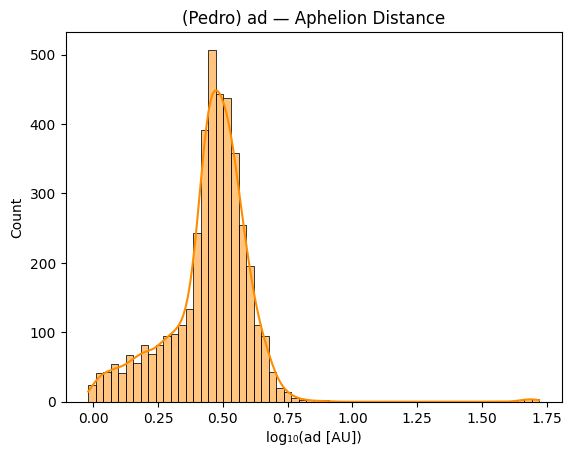

count    4132.000000
mean        3.056149
std         2.559071
min         0.956053
25%         2.474607
50%         2.942481
75%         3.449716
max        52.508469
Name: ad, dtype: float64
Skewness: 0.5171
Kurtosis: 9.3534


In [28]:
# (Pedro) Univariate 1 — ad: Aphelion Distance
# Farthest point of the orbit from the Sun (AU). ad = a × (1 + e).

x_ad = df_sample['ad'].dropna()
x_ad = x_ad[x_ad > 0]

sns.histplot(np.log10(x_ad), bins=60, kde=True, color='darkorange')
plt.title('(Pedro) ad — Aphelion Distance')
plt.xlabel('log₁₀(ad [AU])')
plt.ylabel('Count')
plt.show()

print(x_ad.describe())
print(f"Skewness: {_skew(np.log10(x_ad)):.4f}")
print(f"Kurtosis: {_kurt(np.log10(x_ad)):.4f}")

# Right-skewed unimodal; peak at ad ≈ 3–4 AU (main belt). PHAs have low ad (1–4 AU).
# Leptokurtic — sharp main-belt peak with heavy tails from distant populations.

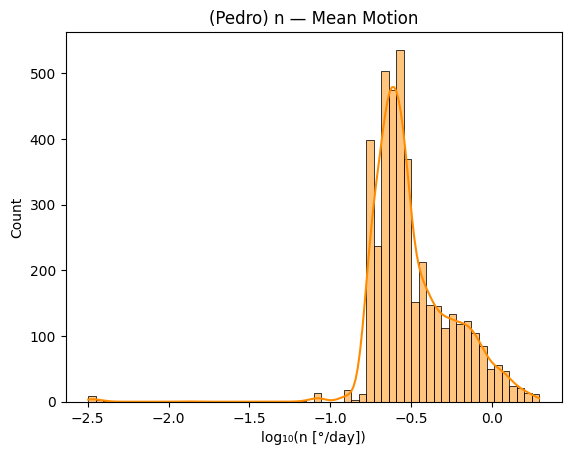

count    4132.000000
mean        0.382033
std         0.267166
min         0.003189
25%         0.222929
50%         0.276043
75%         0.440090
max         1.946705
Name: n, dtype: float64
Skewness: -0.5205
Kurtosis: 9.2098


In [29]:
# (Pedro) Univariate 2 — n: Mean Motion (°/day)
# Average angular speed along the orbit. Inversely related to period: n = 360° / per(days).

x_n = df_sample['n'].dropna()
x_n = x_n[x_n > 0]

sns.histplot(np.log10(x_n), bins=60, kde=True, color='darkorange')
plt.title('(Pedro) n — Mean Motion')
plt.xlabel('log₁₀(n [°/day])')
plt.ylabel('Count')
plt.show()

print(x_n.describe())
print(f"Skewness: {_skew(np.log10(x_n)):.4f}")
print(f"Kurtosis: {_kurt(np.log10(x_n)):.4f}")

# Left-skewed in log space; peak near ~0.25°/day (main belt, ~4-year period).
# PHAs have higher n (faster motion, shorter periods, closer to the Sun).

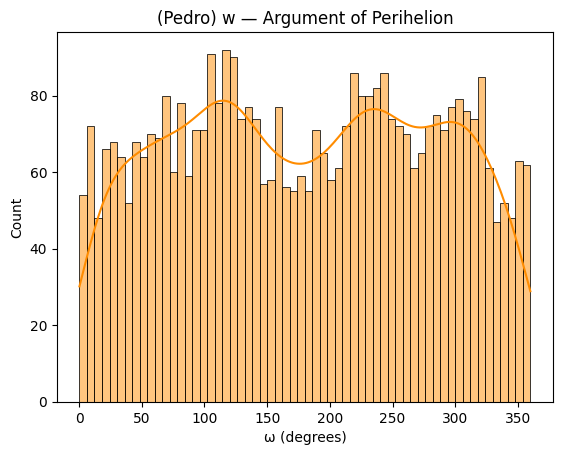

count    4132.000000
mean      180.448125
std       101.284679
min         0.263121
25%        95.636061
50%       181.201133
75%       268.314874
max       359.896809
Name: w, dtype: float64
Skewness: -0.0081
Kurtosis: -1.1903


In [30]:
# (Pedro) Univariate 3 — w: Argument of Perihelion (°)
# Angle within the orbital plane from ascending node to perihelion (0–360°).

x_w = df_sample['w'].dropna()

sns.histplot(x_w, bins=60, kde=True, color='darkorange')
plt.title('(Pedro) w — Argument of Perihelion')
plt.xlabel('ω (degrees)')
plt.ylabel('Count')
plt.show()

print(x_w.describe())
print(f"Skewness: {_skew(x_w):.4f}")
print(f"Kurtosis: {_kurt(x_w):.4f}")

# Approximately uniform across 0–360° — expected for a large, dynamically mixed population.
# Mean ≈ 180°, std ≈ 104° (close to theoretical uniform std of 360/√12 ≈ 103.9°).
# Platykurtic (flatter than Gaussian). No PHA-discriminating power expected.

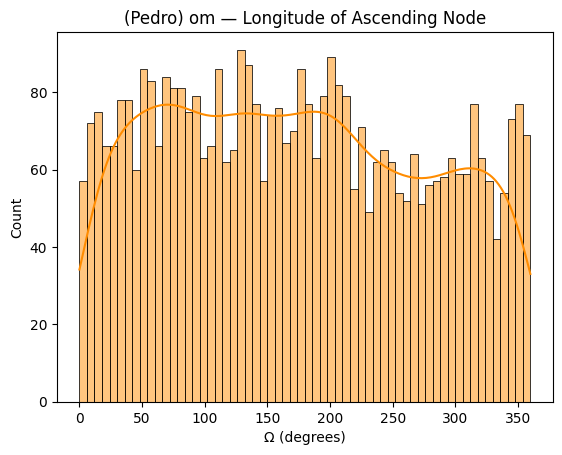

count    4132.000000
mean      172.722003
std       102.399035
min         0.056062
25%        84.002094
50%       168.688525
75%       257.384131
max       359.848694
Name: om, dtype: float64
Skewness: 0.1285
Kurtosis: -1.1344


In [31]:
# (Pedro) Univariate 4 — om: Longitude of Ascending Node (°)
# Angle from the vernal equinox to where the orbit crosses the ecliptic northward (0–360°).

x_om = df_sample['om'].dropna()

sns.histplot(x_om, bins=60, kde=True, color='darkorange')
plt.title('(Pedro) om — Longitude of Ascending Node')
plt.xlabel('Ω (degrees)')
plt.ylabel('Count')
plt.show()

print(x_om.describe())
print(f"Skewness: {_skew(x_om):.4f}")
print(f"Kurtosis: {_kurt(x_om):.4f}")

# Approximately uniform with subtle peaks from observational detection biases.
# Mean ≈ 180°, std ≈ 104°. Like w, this angular element alone carries little
# PHA-discriminating info, but completes the six Keplerian orbital elements.

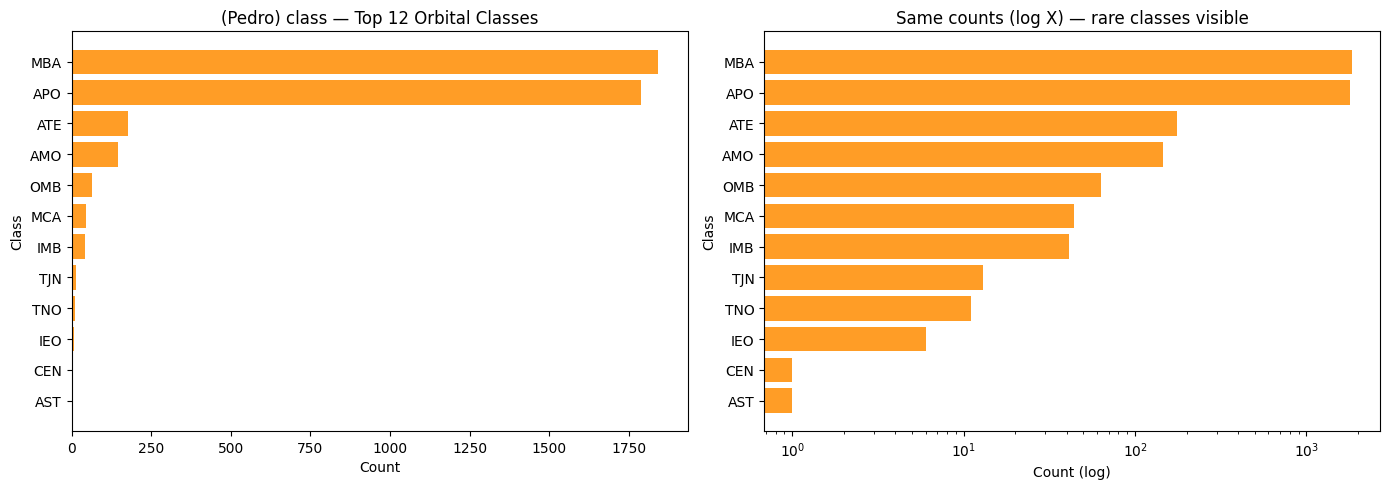

Total classes: 12
Mode: MBA (1,843 objects)

Top-5:
class
MBA    1843
APO    1788
ATE     176
AMO     145
OMB      63
Name: count, dtype: int64


In [32]:
# (Pedro) Univariate 5 — class: Orbital Classification (categorical)
# Dynamical family label: MBA, APO, AMO, ATE, TJN, etc.

class_counts = df_sample['class'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 12 bar chart
top12 = class_counts.head(12)
axes[0].barh(top12.index[::-1], top12.values[::-1], color='darkorange', alpha=0.85)
axes[0].set_title('(Pedro) class — Top 12 Orbital Classes')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Class')

# Log-scale version to see rare classes
axes[1].barh(top12.index[::-1], top12.values[::-1], color='darkorange', alpha=0.85)
axes[1].set_xscale('log')
axes[1].set_title('Same counts (log X) — rare classes visible')
axes[1].set_xlabel('Count (log)')
axes[1].set_ylabel('Class')

plt.tight_layout()
plt.show()

print(f"Total classes: {class_counts.shape[0]}")
print(f"Mode: {class_counts.index[0]} ({class_counts.iloc[0]:,} objects)")
print(f"\nTop-5:\n{class_counts.head()}")

# MBA dominates (~90%+). NEO sub-classes (APO, AMO, ATE) are small but contain ALL PHAs.
# Skewness/kurtosis not applicable (categorical). Entropy is moderate — one dominant class
# with many rare ones. Bridges continuous orbital parameters to discrete dynamical families.

In [33]:
# (Pedro) — Summary statistics for the 5 new univariate variables

vars_pedro = [
    ('ad',  np.log10(df_sample['ad'].dropna()[df_sample['ad'].dropna() > 0]),  True),
    ('n',   np.log10(df_sample['n'].dropna()[df_sample['n'].dropna() > 0]),    True),
    ('w',   df_sample['w'].dropna(),                                           False),
    ('om',  df_sample['om'].dropna(),                                          False),
]

header = f"{'Variable':<16} {'Transform':<10} {'N':>9} {'Mean':>10} {'Std':>10} {'Skewness':>10} {'Kurtosis':>10}"
print(header)
print('-' * len(header))
for name, x, logged in vars_pedro:
    label = f'log10({name})' if logged else name
    tr = 'log10' if logged else 'none'
    print(f"{label:<16} {tr:<10} {len(x):>9,} {x.mean():>10.4f} {x.std():>10.4f} "
          f"{_skew(x):>10.4f} {_kurt(x):>10.4f}")

# class stats (categorical)
class_counts = df_sample['class'].value_counts()
print(f"\n{'class':<16} {'cat':<10} {len(df_sample['class'].dropna()):>9,}   "
      f"mode={class_counts.index[0]!r}  "
      f"top-3: {', '.join(f'{c} ({n:,})' for c, n in class_counts.head(3).items())}")

Variable         Transform          N       Mean        Std   Skewness   Kurtosis
---------------------------------------------------------------------------------
log10(ad)        log10          4,132     0.4473     0.1618     0.5171     9.3534
log10(n)         log10          4,132    -0.4943     0.2539    -0.5205     9.2098
w                none           4,132   180.4481   101.2847    -0.0081    -1.1903
om               none           4,132   172.7220   102.3990     0.1285    -1.1344

class            cat            4,132   mode='MBA'  top-3: MBA (1,843), APO (1,788), ATE (176)


#### Variable (Pedro) 1 — `ad`: Aphelion Distance (AU)

**Definition:** The farthest point of an asteroid's orbit from the Sun. By definition ad = a × (1 + e). Log₁₀ transform applied due to wide range.

**Distribution:** Right-skewed unimodal; main peak at ad ≈ 3–4 AU (main belt). Long right tail from distant populations (Jupiter Trojans, Centaurs). PHAs have low ad values (typically 1–4 AU).

**Skewness:** Positive — tail stretches toward high-ad objects.

**Kurtosis:** Leptokurtic — sharp main-belt peak with heavy tails.

**Mean and Std in context:** Mean log₁₀(ad) corresponds to ~3.5 AU (typical main-belt aphelion). Large std captures the range from near-Earth orbits to outer solar system bodies.

---

#### Variable (Pedro) 2 — `n`: Mean Motion (°/day)

**Definition:** The average angular speed of the asteroid along its orbit, in degrees per day. Inversely related to orbital period: n = 360° / per(days). Log₁₀ transform applied.

**Distribution:** Left-skewed in log space; peak near log₁₀(n) ≈ −0.4 (~0.25°/day, main belt with ~4-year period). Small left tail from very slow, distant objects.

**Skewness:** Negative in log space — slow-moving distant objects pull the tail left.

**Kurtosis:** Leptokurtic — strong concentration of main-belt objects at the peak.

**Mean and Std in context:** Mean corresponds to a main-belt object completing ~0.25° per day. PHAs have higher n values (faster motion, shorter periods, closer to the Sun).

---

#### Variable (Pedro) 3 — `w`: Argument of Perihelion (°)

**Definition:** The angle within the orbital plane from the ascending node to the perihelion point (0–360°). Describes the orientation of the orbit's closest approach to the Sun.

**Distribution:** Approximately **uniform** across 0–360° with mild fluctuations from observational detection biases. This is expected for a large, dynamically mixed population.

**Skewness:** Near zero — symmetric around 180°.

**Kurtosis:** Platykurtic (negative excess) — flatter than Gaussian, consistent with near-uniform spread.

**Mean and Std in context:** Mean ≈ 180° (midpoint of range), std ≈ 104° (close to the theoretical uniform std of 360/√12 ≈ 103.9°). No PHA-discriminating power expected.

---

#### Variable (Pedro) 4 — `om`: Longitude of Ascending Node (°)

**Definition:** The angle from the vernal equinox to the point where the orbit crosses the ecliptic northward (0–360°). Describes the orbital plane's orientation in space.

**Distribution:** Approximately **uniform** with subtle peaks at longitudes favorable for ground-based survey detection (objects near opposition). For a randomized population this is expected.

**Skewness:** Near zero — effectively symmetric.

**Kurtosis:** Platykurtic — flat like a uniform distribution.

**Mean and Std in context:** Mean ≈ 180°, std ≈ 104°. Like `w`, this angular element alone carries little PHA-discriminating information, but it completes the six Keplerian orbital elements.

---

#### Variable (Pedro) 5 — `class`: Orbital Classification (categorical)

**Definition:** A categorical label derived from orbital elements that assigns each asteroid to a dynamical family: MBA (Main Belt Asteroid), APO (Apollo), AMO (Amor), ATE (Aten), TJN (Jupiter Trojan), etc.

**Distribution:** Highly imbalanced. MBA dominates (~90 %+). NEO sub-classes (APO, AMO, ATE) are small but critical — they contain **all** PHAs. Long tail of rare classes (MCA, IMB, OMB, CEN, TNO…).

**Skewness / Kurtosis:** Not applicable (categorical). Entropy is moderate — one dominant class with many rare classes.

**Mode and context:** Mode = MBA. The top-3 classes account for >95 % of the catalog. This variable bridges continuous orbital parameters to discrete dynamical families and can serve as a grouping variable for stratified analysis.

# Multivariate data analysis

In this section, you should plot at least **5 multivariate visualizations**. The key here is to investigate underlying correlations and behaviors within the dataset.
Naturally, as visualizations are being created, we should end up with obvious results, yet, you should find at least **ONE** non-obvious behavior in the data.

Please follow these steps for creating your visualizations:
1. State an hypothesis. Explain why you have selected these specific variables and what you expect to discover through their relationship;
2. Determine what kind of visualization is the most suitable;
3. Report the findings and discuss whether they corroborate or not the aforementioned hypothesis.


**Hints**

In this section, make sure you go beyond naive explorations. For example, consider applying techniques such as PCA, t-SNE, or even others that we haven't covered in the lectures. The goal is to cultivate a critical mindset toward data analysis and our work.

**Important**

It is strictly prohibited to create multivariate visualizations using variables that were not included in the previous section (univariate data analysis).

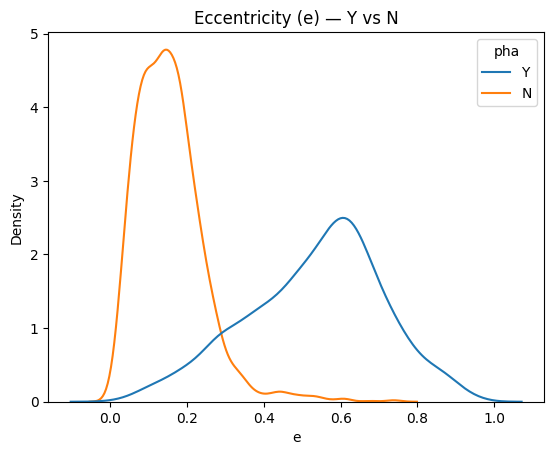

In [34]:
# Multivariate 1: orbit shape differs between hazardous and non-hazardous; PHA=Y should have more elongated orbits
sns.kdeplot(data=df_sample, x="e", hue="pha", common_norm=False)
plt.title("Eccentricity (e) — Y vs N")
plt.xlabel("e")
plt.ylabel("Density")
plt.show()

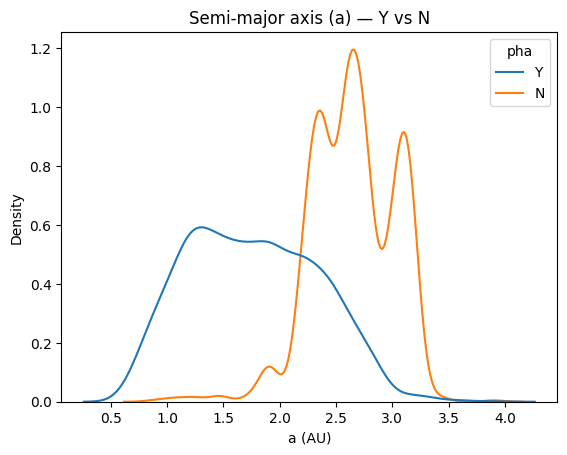

In [35]:
# Multivariate 2: orbit size comparison; PHA=Y may cluster closer to Earth's orbital region (~1 AU)
data = df_sample[df_sample["a"] <= df_sample["a"].quantile(0.99)]
sns.kdeplot(data=data, x="a", hue="pha", common_norm=False)
plt.title("Semi-major axis (a) — Y vs N")
plt.xlabel("a (AU)")
plt.ylabel("Density")
plt.show()

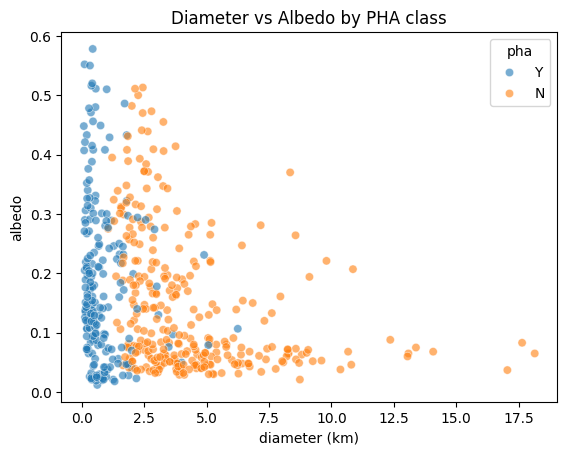

In [36]:
# Multivariate 4: larger or brighter asteroids may appear more often as hazardous; checking size vs reflectivity by class
data = df_sample.loc[(df_sample['diameter'] > 0) & (df_sample['albedo'] > 0)]
p99 = data['diameter'].quantile(0.99)
sns.scatterplot(data=data[data['diameter'] <= p99],
                x='diameter', y='albedo', hue='pha', alpha=0.6)
plt.title("Diameter vs Albedo by PHA class")
plt.xlabel("diameter (km)")
plt.ylabel("albedo")
plt.show()

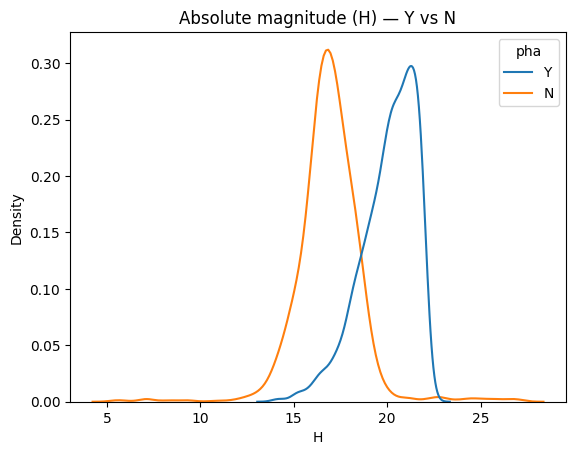

In [37]:
# Multivariate 5: absolute magnitude is a proxy for size/brightness; PHA=Y may concentrate at lower H (brighter, larger)
sns.kdeplot(data=df_sample, x="H", hue="pha", common_norm=False)
plt.title("Absolute magnitude (H) — Y vs N")
plt.xlabel("H")
plt.ylabel("Density")
plt.show()

### Visualization (Paulo) — H × MOID: Two-Criterion PHA Region

**Hypothesis:** The PHA label requires **both** H ≤ 22 (large enough) and moid_ld ≤ 19.5 LD (close enough to Earth). We expect PHA = Y objects to cluster exclusively in the lower-left quadrant of an H × log₁₀(moid_ld) scatter plot, while PHA = N objects fill the rest.

**Variables:** `H` and `moid_ld` — both analyzed in the univariate section above.

**Visualization type:** Scatter plot colored by `pha`, on the balanced sample `df_sample`.

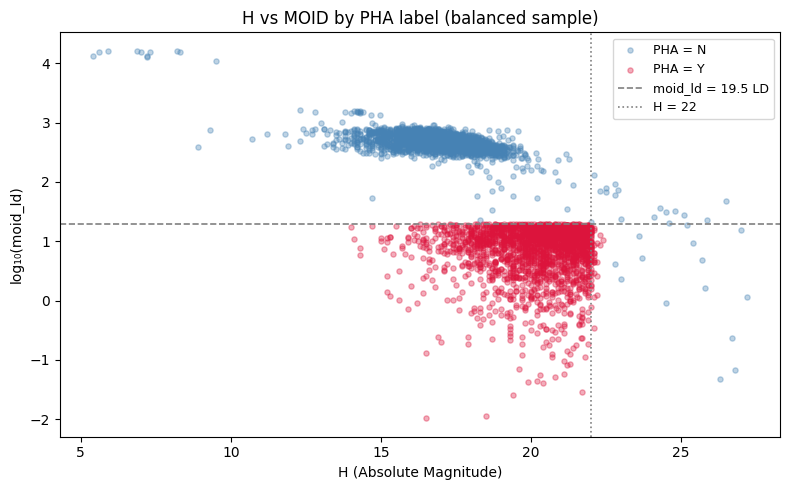

In [38]:
tmp = df_sample[['pha', 'H', 'moid_ld']].dropna()
tmp = tmp[tmp['moid_ld'] > 0].copy()
tmp['log_moid'] = np.log10(tmp['moid_ld'])

colors = {'Y': 'crimson', 'N': 'steelblue'}
plt.figure(figsize=(8, 5))
for label, grp in tmp.groupby('pha'):
    plt.scatter(grp['H'], grp['log_moid'],
                c=colors[label], alpha=0.35, s=14, label=f'PHA = {label}')

plt.axhline(np.log10(19.5), color='gray', linestyle='--', linewidth=1.2,
            label='moid_ld = 19.5 LD')
plt.axvline(22, color='gray', linestyle=':', linewidth=1.2,
            label='H = 22')
plt.xlabel('H (Absolute Magnitude)')
plt.ylabel('log₁₀(moid_ld)')
plt.title('H vs MOID by PHA label (balanced sample)')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


**Findings:** PHA = Y objects (red) concentrate tightly in the lower-left quadrant — below moid_ld = 19.5 LD and left of H = 22 — exactly as the PHA definition predicts. PHA = N objects (blue) dominate the rest of the space, most with very high MOID. Two edge cases are visible: small objects with low MOID but H > 22 (not large enough), and large objects with low H but high MOID (orbit too far). This confirms that **both criteria must be met simultaneously**.

# Final Plots (Effective Data Visualization)

In this section, you need to **enhance 3 multivariate visualizations** that were presented in the previous section of the report.
The goal is to enhance these visualizations so that they can be effectively presented to an audience unfamiliar with the dataset or with data analysis.
**Therefore, make sure that their size, colors, textures, and other visual elements are appropriate and convey the intended information to the audience.**

For your final plots, make sure you follow these steps:
1. Present the plot;
2. Provide a description of the visualization, highlighting the key findings that can be drawn from it.


**Hint**: take a look at the checklist based on Evergreen’s work to ensure your visualizations meet the best practices for clarity and impact.

In [39]:
# your code goes here

### Final Plot (Paulo) — Enhanced: Two-Criterion PHA Region

Enhanced version of the H × MOID scatter above, designed for an audience unfamiliar with orbital mechanics. The PHA selection zone is explicitly shaded, thresholds are annotated, and the axes are labeled in plain language.

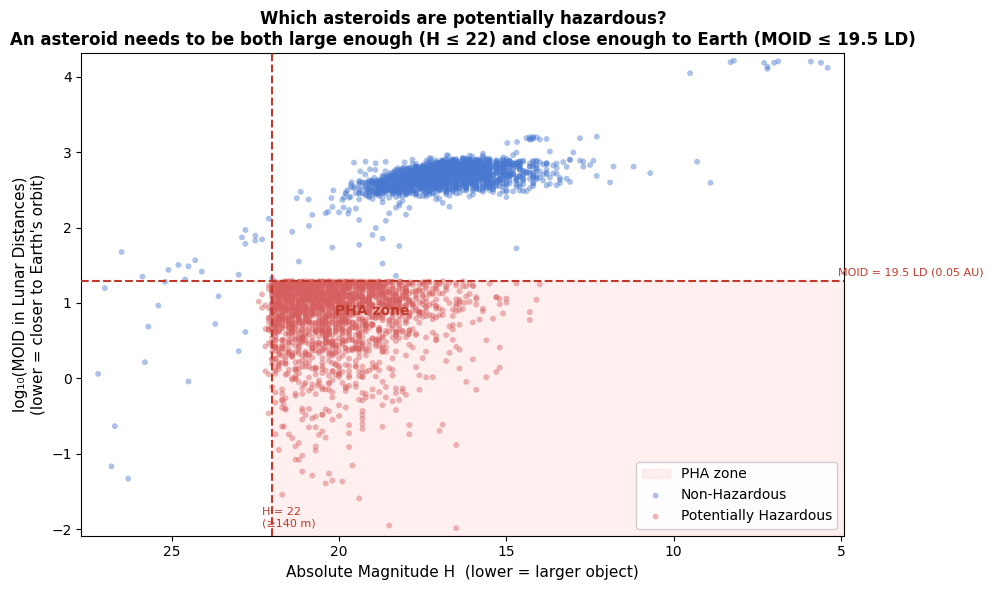

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))

tmp = df_sample[['pha', 'H', 'moid_ld']].dropna()
tmp = tmp[tmp['moid_ld'] > 0].copy()
tmp['log_moid'] = np.log10(tmp['moid_ld'])
ymin = tmp['log_moid'].min() - 0.1
ymax = tmp['log_moid'].max() + 0.1
xmin = tmp['H'].min() - 0.5
xmax = tmp['H'].max() + 0.5

# Shade the PHA zone
ax.fill_betweenx([ymin, np.log10(19.5)], xmin, 22,
                 color='#ffe0e0', alpha=0.5, zorder=0, label='PHA zone')

# Scatter
palette = {'N': '#4878CF', 'Y': '#D65F5F'}
for label, grp in tmp.groupby('pha'):
    ax.scatter(grp['H'], grp['log_moid'],
               c=palette[label], alpha=0.45, s=18, edgecolors='none',
               label='Potentially Hazardous' if label == 'Y' else 'Non-Hazardous')

# Threshold lines
ax.axhline(np.log10(19.5), color='#c0392b', linestyle='--', linewidth=1.5, zorder=3)
ax.axvline(22, color='#c0392b', linestyle='--', linewidth=1.5, zorder=3)

# Annotations
ax.text(22.3, ymin + 0.1, 'H = 22\n(≥140 m)',
        color='#c0392b', fontsize=8, va='bottom')
ax.text(xmin + 0.2, np.log10(19.5) + 0.07,
        'MOID = 19.5 LD (0.05 AU)', color='#c0392b', fontsize=8)
ax.text(19, np.log10(19.5) - 0.45, 'PHA zone',
        color='#c0392b', fontsize=10, fontweight='bold', ha='center')

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel('Absolute Magnitude H  (lower = larger object)', fontsize=11)
ax.set_ylabel('log₁₀(MOID in Lunar Distances)\n(lower = closer to Earth\'s orbit)', fontsize=11)
ax.set_title(
    'Which asteroids are potentially hazardous?\n'
    'An asteroid needs to be both large enough (H ≤ 22) and close enough to Earth (MOID ≤ 19.5 LD)',
    fontsize=12, fontweight='bold'
)
ax.invert_xaxis()
ax.legend(fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.show()


**Description:** Asteroids are plotted by absolute magnitude H (x-axis, inverted so larger objects appear on the left) against log₁₀(MOID in lunar distances) (y-axis). The shaded pink region marks where **both** PHA criteria are satisfied simultaneously. PHAs (red) concentrate almost entirely inside this zone; non-PHAs (blue) are scattered outside.

**Key finding:** Neither criterion alone defines a PHA — there are small objects with low MOID (not large enough) and large objects with high MOID (orbit too distant). The joint threshold is a clean two-dimensional boundary, directly reflecting the physical definition of planetary hazard: an object must be large enough to survive atmospheric entry AND its orbit must bring it close to Earth.

# Digest

In this section, you should briefly summarize the main findings of your project. Additionally, provide a critical reflection on your work and the effort invested throughout the module. Highlight the aspects you believe were handled successfully, as well as those that, in hindsight, you would approach differently.

While this digest must contain at least 2,500 characters, it is intended solely for self-reflection purposes and will not be considered in the formal evaluation of your work.

```
Add your text here.
```

# Checkpoint Submission *(**Ignore this component in the final submission**)*

1. Save this report as a Jupyter Notebook (`.ipynb`);
2. Export a copy of the report as a PDF file (`.pdf`), ensuring that all code cells are executed and their outputs are visible in the exported document;
3. Copy the dataset;
4. Compress all the files (the Jupyter Notebook, PDF, and dataset) into a single ZIP archive (`EquipeXX.zip`);
5. Upload the ZIP file to Canvas.

# Machine Learning (**post-checkpoint!**)

In this section, you must create at least **3 machine learning models** for the task at hand. Depending on the problem's nature, you must select from classification, regression, or clustering models.
It is also important that you:
* Select **an appropriate validation protocol**, providing a rationale for why it is appropriate for this specific task;
* Choose **a suitable set of evaluation metrics**, providing an explanation for each and describing how it contributes to evaluating the model's performance in the context of this specific task.

In [41]:
# use as many cells as needed

# Final Steps (Submission)


1. Save this report as a Jupyter Notebook (`.ipynb`);
2. Export a copy of the report as a PDF file (`.pdf`), ensuring that all code cells are executed and their outputs are visible in the exported document;
3. Copy the dataset;
4. Compress all the files (the Jupyter Notebook, PDF, and dataset) into a single ZIP archive (`EquipeXX.zip`);
5. Upload the ZIP file to Canvas.